# Weltbilder im Vergleich — Eudoxos, Ptolemäus, Kopernikus, Tycho, Kepler, Newton

Wie ist die Welt aufgebaut, und wer steht im Mittelpunkt? Über gut 2000 Jahre wurden sehr
verschiedene Antworten gegeben. Jede war ein **Rechenmodell**, das Planetenpositionen am Himmel
vorhersagen sollte. In diesem Notebook bauen wir die wichtigsten Weltbilder nach, lassen sie
gegeneinander antreten und suchen die Beobachtungen, die zwischen ihnen entscheiden.

| Weltbild | Zeit | Zentrum | Idee |
|---|---|---|---|
| **Eudoxos** (homozentrische Sphären) | ≈ 370 v. Chr. | Erde | ineinander rotierende Kugelschalen, alle um die Erde zentriert |
| **Ptolemäus** (Almagest) | ≈ 150 n. Chr. | Erde | Deferent + Epizykel + Exzenter + Äquant |
| **Kopernikus** (De revolutionibus) | 1543 | Sonne | Planeten *und Erde* auf Kreisen um die Sonne |
| **Tycho Brahe** | 1588 | Erde | Sonne kreist um die ruhende Erde, alle anderen Planeten um die Sonne |
| **Kepler** (Astronomia nova) | 1609 | Sonne | Ellipsen, Sonne in einem Brennpunkt, Flächensatz |
| **Newton** (Principia) | 1687 | Schwerpunkt | Gravitationsgesetz; Kepler-Bahnen folgen daraus |

**Aufbau**

1. Referenz: die „wahren“ Bahnen (moderne Kepler-Elemente)
2. – 6. die einzelnen Weltbilder
7. Alles eine Frage des Bezugssystems?
8. Genauigkeitswettbewerb
9. Beobachtungen, die entscheiden (Helligkeit, Venusphasen, Parallaxe, 3. Keplersches Gesetz)
10. Newton: Gravitation als Ursache
11. Animation, Einordnung, Aufgaben

Die Details des ptolemäischen Modells stehen im Notebook `ptolemaeisches_weltbild.ipynb`; hier
geht es um den **Vergleich**. Alle Modelle sind **eben** (Bahnneigungen werden vernachlässigt).

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.patches import Circle

%matplotlib inline
plt.rcParams["figure.figsize"] = (8, 8)
plt.rcParams["axes.grid"] = True
plt.rcParams["grid.alpha"] = 0.25

# feste Farbe pro Himmelskörper und pro Weltbild (Farbe folgt dem Objekt, nie der Plot-Reihenfolge)
FARBE = {
    "Merkur":  "#2a78d6",
    "Venus":   "#eb6834",
    "Erde":    "#3a3a38",
    "Mars":    "#1baf7a",
    "Jupiter": "#eda100",
    "Saturn":  "#e87ba4",
    "Sonne":   "#c98500",
}
MODELL_FARBE = {
    "Eudoxos":    "#8c8c88",
    "Ptolemäus":  "#eb6834",
    "Kopernikus": "#2a78d6",
    "Tycho":      "#4a3aa7",
    "Kepler":     "#1baf7a",
}

JAHR = 365.25                  # Tage
BOGENMIN = 60                  # Bogenminuten pro Grad

## 1. Referenz: die „wahren“ Bahnen

Als Maßstab benutzen wir **Kepler-Ellipsen mit modernen Bahnelementen** (Epoche J2000). Das ist
auf etwa eine Bogenminute genau — viel genauer, als die Modelle vor Kepler je waren.

| Symbol | Bedeutung |
|---|---|
| $a$ | große Halbachse [AE] |
| $e$ | Exzentrizität |
| $\varpi$ | Länge des Perihels [°] |
| $L_0$ | mittlere Länge zur Zeit $t=0$ (1. Januar 2000) [°] |
| $T$ | siderische Umlaufzeit [Jahre] |

Position auf der Ellipse: mittlere Anomalie $M = L - \varpi$, Kepler-Gleichung
$M = E - e\sin E$ (numerisch nach $E$ auflösen), dann

$$x' = a(\cos E - e), \qquad y' = a\sqrt{1-e^2}\,\sin E$$

und Drehung um $\varpi$. Die Sonne sitzt im Ursprung (Brennpunkt).

In [2]:
#                a [AE]    e        ϖ [°]     L0 [°]    T [Jahre]
ELEMENTE = {
    "Merkur":  (0.38710, 0.20563,  77.456, 252.251,  0.240846),
    "Venus":   (0.72333, 0.00677, 131.530, 181.980,  0.615198),
    "Erde":    (1.00000, 0.01671, 102.947, 100.464,  1.000017),
    "Mars":    (1.52368, 0.09340, 336.040, 355.453,  1.880848),
    "Jupiter": (5.20260, 0.04849,  14.331,  34.351, 11.862615),
    "Saturn":  (9.55491, 0.05551,  93.057,  50.077, 29.447498),
}
PLANETEN = [n for n in ELEMENTE if n != "Erde"]
INNEN = {"Merkur", "Venus"}


def richtung(winkel):
    """Einheitsvektor(en) zum Winkel [rad] — Form (..., 2)."""
    winkel = np.asarray(winkel)
    return np.stack([np.cos(winkel), np.sin(winkel)], axis=-1)


def mittlere_laenge(name, t):
    """Mittlere (gleichförmig wachsende) heliozentrische Länge [rad] zur Zeit t [Jahre]."""
    a, e, w, L0, T = ELEMENTE[name]
    return np.radians(L0) + 2 * np.pi * np.asarray(t) / T


def kepler(name, t):
    """Heliozentrische Position auf der Kepler-Ellipse [AE] — unsere Referenz."""
    a, e, w, L0, T = ELEMENTE[name]
    M = mittlere_laenge(name, t) - np.radians(w)
    E = np.array(M, dtype=float)
    for _ in range(40):                       # Newton-Verfahren für M = E - e sin E
        E -= (E - e * np.sin(E) - M) / (1 - e * np.cos(E))
    x, y = a * (np.cos(E) - e), a * np.sqrt(1 - e**2) * np.sin(E)
    c, s = np.cos(np.radians(w)), np.sin(np.radians(w))
    return np.stack([c * x - s * y, s * x + c * y], axis=-1)


def geo_referenz(name, t):
    """Geozentrische Position Erde → Planet (bzw. Sonne) aus den Kepler-Bahnen."""
    erde = kepler("Erde", t)
    return -erde if name == "Sonne" else kepler(name, t) - erde


def laenge(pos):
    """Ekliptikale Länge [°] (stetig fortgesetzt)."""
    return np.degrees(np.unwrap(np.arctan2(pos[..., 1], pos[..., 0])))


def winkelfehler(lam1, lam2):
    """Differenz zweier Längen [°] → Bogenminuten im Bereich ±180°."""
    return ((np.asarray(lam1) - lam2 + 180) % 360 - 180) * BOGENMIN


def synodisch(name):
    """Synodische Periode [Jahre] (z. B. Opposition → Opposition)."""
    return 1 / abs(1 / ELEMENTE[name][4] - 1 / ELEMENTE["Erde"][4])


print(f"{'Planet':<9}{'a [AE]':>8}{'e':>8}{'T [a]':>9}{'synod. Periode':>17}")
for n in PLANETEN:
    a, e, _, _, T = ELEMENTE[n]
    print(f"{n:<9}{a:>8.3f}{e:>8.3f}{T:>9.2f}{synodisch(n) * JAHR:>12.0f} Tage")

Planet     a [AE]       e    T [a]   synod. Periode
Merkur      0.387   0.206     0.24         116 Tage
Venus       0.723   0.007     0.62         584 Tage
Mars        1.524   0.093     1.88         780 Tage
Jupiter     5.203   0.048    11.86         399 Tage
Saturn      9.555   0.056    29.45         378 Tage


## 2. Eudoxos: homozentrische Sphären

Eudoxos von Knidos erlaubte **nur Kugeln um die Erde**. Jeder Planet sitzt auf einem Satz
ineinander gelagerter Sphären:

1. Sphäre: tägliche Drehung des Himmels (für uns uninteressant, wir rechnen in Ekliptik-Koordinaten)
2. Sphäre: langsame Wanderung durch den Tierkreis (siderische Periode)
3. + 4. Sphäre: drehen sich **gleich schnell, aber gegensinnig** mit der synodischen Periode;
   die Achse der 4. ist um den Winkel $i$ gegen die der 3. geneigt.

Die Achse der 3. Sphäre liegt in der Ekliptik. Sphären 3 und 4 zusammen führen den Planeten
auf einer liegenden Acht, der **Hippopede** („Pferdefessel“). Ihre halbe Länge entlang der
Ekliptik ist genau $i$. Addiert man die Tierkreisbewegung, läuft der Planet zeitweise rückwärts.

Wichtige Eigenschaft: Der Abstand Erde–Planet ist **immer gleich**.

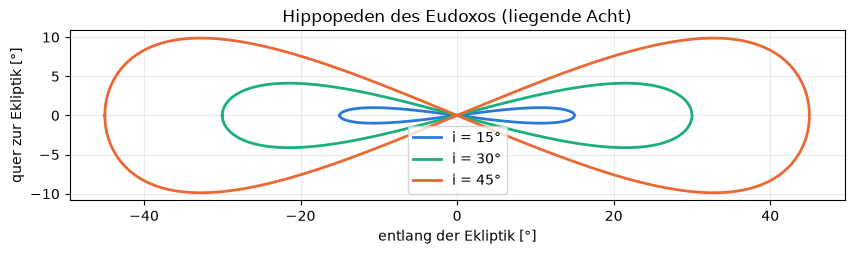

In [3]:
def drehung(achse, winkel, punkt):
    """Rodrigues-Formel: Punkt um eine Einheitsachse drehen (winkel als Array)."""
    w = np.asarray(winkel)[..., None]
    return (punkt * np.cos(w) + np.cross(achse, punkt) * np.sin(w)
            + achse * np.sum(achse * punkt, axis=-1, keepdims=True) * (1 - np.cos(w)))


def hippopede(theta, i):
    """Sphären 3+4 des Eudoxos.

    Koordinaten: z = Achse der 3. Sphäre (liegt in der Ekliptik).
    Rückgabe: (Versatz entlang der Ekliptik, Versatz quer dazu) in Grad.
    """
    achse4 = np.array([0.0, np.sin(i), np.cos(i)])       # 4. Achse, um i gegen z geneigt
    p0 = np.array([0.0, np.cos(i), -np.sin(i)])          # Planet am Äquator der 4. Sphäre
    p = drehung(achse4, theta, p0)                       # 4. Sphäre dreht um +theta …
    p = drehung(np.array([0.0, 0.0, 1.0]), -theta, p)    # … und die 3. um −theta
    laengs = np.degrees(np.arcsin(np.clip(p[..., 2], -1, 1)))
    quer = np.degrees(np.arctan2(p[..., 1], p[..., 0])) - 90
    return laengs, quer


fig, ax = plt.subplots(figsize=(10, 4.5))
theta = np.linspace(0, 2 * np.pi, 600)
for i_grad, farbe in ((15, "#2a78d6"), (30, "#1baf7a"), (45, "#eb6834")):
    laengs, quer = hippopede(theta, np.radians(i_grad))
    ax.plot(laengs, quer, color=farbe, lw=2, label=f"i = {i_grad}°")
ax.set(xlabel="entlang der Ekliptik [°]", ylabel="quer zur Ekliptik [°]",
       title="Hippopeden des Eudoxos (liegende Acht)", aspect="equal")
ax.legend()
plt.show()

Jetzt das ganze Modell. Die Hippopede läuft mit der synodischen Periode und ist so
ausgerichtet, dass ihr Rückwärtsast in die **Opposition** (äußere Planeten) bzw. die **untere
Konjunktion** (innere Planeten) fällt. Ihr Mittelpunkt wandert mit der mittleren Bewegung des
Planeten (äußere) bzw. der mittleren Sonne (innere) durch den Tierkreis.

Den Neigungswinkel $i$ — den einzigen freien Parameter — wählen wir für jeden Planeten so, dass
der Fehler gegenüber der Referenz möglichst klein wird. Eudoxos hätte es nicht besser gekonnt.

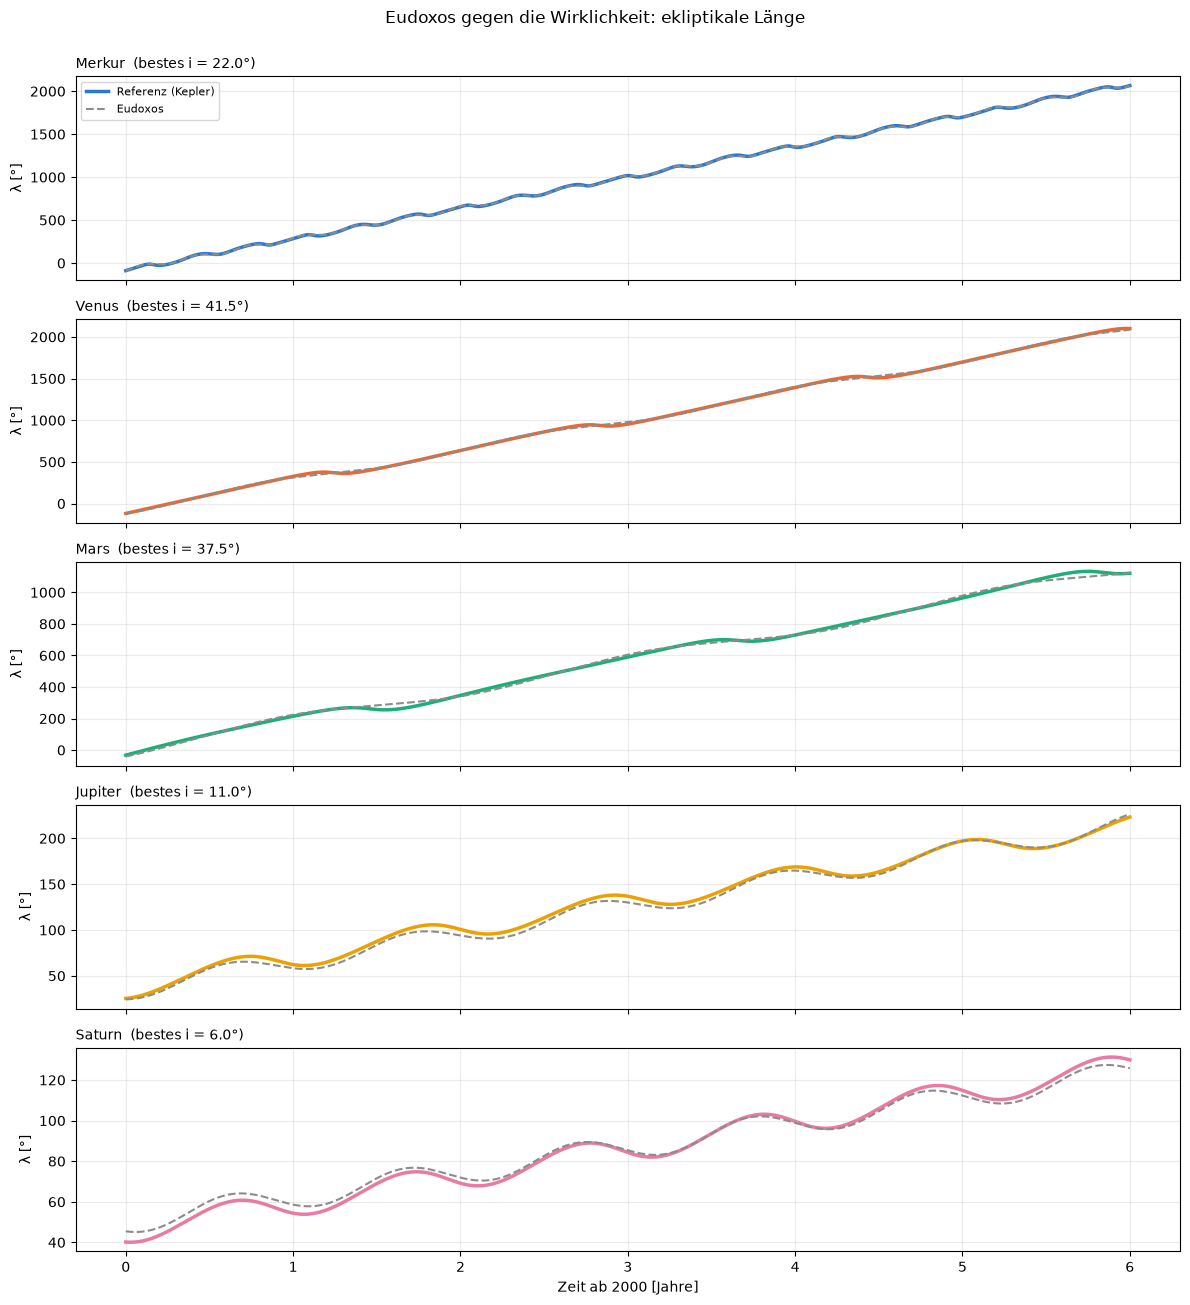

In [4]:
def synodische_phase(name, t):
    # 0 bei Opposition bzw. unterer Konjunktion, wächst gleichmäßig mit der Zeit
    phi = mittlere_laenge(name, t) - mittlere_laenge("Erde", t)
    return phi if name in INNEN else -phi


def eudoxos(name, t, i):
    """Geozentrische Länge [°] nach Eudoxos (Abstand ist konstant, daher nur die Richtung)."""
    zentrum = mittlere_laenge("Erde", t) + np.pi if name in INNEN else mittlere_laenge(name, t)
    laengs, _ = hippopede(synodische_phase(name, t) + 1.5 * np.pi, i)
    return np.degrees(zentrum) + laengs


def bester_winkel(name, t):
    ref = laenge(geo_referenz(name, t))
    kandidaten = np.radians(np.arange(1, 120, 0.5))
    rms = [np.sqrt(np.mean(winkelfehler(eudoxos(name, t, i), ref) ** 2)) for i in kandidaten]
    return kandidaten[int(np.argmin(rms))]


t_fit = np.linspace(0, 30, 6000)
EUDOXOS_I = {n: bester_winkel(n, t_fit) for n in PLANETEN}

fig, axes = plt.subplots(len(PLANETEN), 1, figsize=(12, 13), sharex=True)
t = np.linspace(0, 6, 4000)
for ax, n in zip(axes, PLANETEN):
    ref = laenge(geo_referenz(n, t))
    eud = np.unwrap(eudoxos(n, t, EUDOXOS_I[n]), period=360)
    eud -= 360 * np.round((eud[0] - ref[0]) / 360)      # gleiche 360°-Windung wie die Referenz
    ax.plot(t, ref, color=FARBE[n], lw=2.5, label="Referenz (Kepler)")
    ax.plot(t, eud, color=MODELL_FARBE["Eudoxos"],
            lw=1.5, ls="--", label="Eudoxos")
    ax.set_title(f"{n}  (bestes i = {np.degrees(EUDOXOS_I[n]):.1f}°)", loc="left", fontsize=10)
    ax.set_ylabel("λ [°]")
axes[0].legend(loc="upper left", fontsize=8)
axes[-1].set_xlabel("Zeit ab 2000 [Jahre]")
fig.suptitle("Eudoxos gegen die Wirklichkeit: ekliptikale Länge", y=1.0)
plt.tight_layout()
plt.show()

Die Grundidee — Rückläufigkeit aus überlagerten Drehungen — ist richtig, aber die Schleifen
sind alle **gleich groß** und **gleich lang**, und der Planet ist immer **gleich weit weg**. In
Wirklichkeit schwanken Größe der Schleifen und Helligkeit stark (besonders bei Mars). Schon in der
Antike war das der Hauptkritikpunkt.

## 3. Ptolemäus: Deferent, Epizykel, Äquant

Ptolemäus gibt die Forderung „alles konzentrisch um die Erde“ auf, hält aber an **gleichförmigen
Kreisbewegungen** fest:

* **äußere Planeten:** Epizykelmittelpunkt auf einem exzentrischen Deferenten; gleichförmig
  läuft er nur vom **Äquant** aus gesehen. Der Epizykelradius zeigt immer zur *mittleren Sonne*.
* **innere Planeten:** Der Epizykelmittelpunkt läuft (mit Äquant) mit der mittleren Sonne,
  der Planet gleichförmig auf dem Epizykel.
* **Sonne:** einfacher Exzenterkreis (Hipparch).

Parameter: Exzentrizität $e$ des Deferenten; Mittelpunkt im Abstand $e\,a$, Äquant im Abstand
$2e\,a$ von der Erde (die „Halbierung der Exzentrizität“).

Mit der Umrechnung „Deferent = Planetenbahn, Epizykel = Erdbahn“ (siehe
`ptolemaeisches_weltbild.ipynb`) benutzen wir dieselben Zahlen wie in der Referenz.

In [5]:
def aequantkreis(name, t, mitte=1.0, aequant=2.0):
    """Exzentrischer Kreis mit Äquant, um den Ursprung (Erde bzw. Sonne) herum.

    Kreismittelpunkt im Abstand mitte·e·a, Äquant im Abstand aequant·e·a, beide zum Aphel hin.
    Vom Äquant aus gesehen läuft der Punkt gleichförmig (mittlere Länge).
    """
    a, e, w, _, _ = ELEMENTE[name]
    apsis = richtung(np.radians(w))
    C, Q = -mitte * e * a * apsis, -aequant * e * a * apsis
    d = richtung(mittlere_laenge(name, t))
    b = np.sum((Q - C) * d, axis=-1)
    c = np.sum((Q - C) ** 2, axis=-1) - a**2
    s = -b + np.sqrt(b**2 - c)                  # Schnitt Strahl ↔ Kreis
    return Q + s[..., None] * d


def mittlere_sonne(t):
    """Geozentrisch: gleichförmiger Kreis, 1 AE (= Richtung der mittleren Sonne)."""
    return richtung(mittlere_laenge("Erde", t) + np.pi)


def ptolemaeus(name, t):
    """Geozentrische Position nach Ptolemäus. Rückgabe: (Planet, Epizykelmittelpunkt)."""
    if name == "Sonne":
        p = -aequantkreis("Erde", t, mitte=2.0, aequant=2.0)   # Exzenter ohne Äquant
        return p, p
    a = ELEMENTE[name][0]
    if name in INNEN:
        zentrum = -aequantkreis("Erde", t)                     # läuft mit der Sonne
        return zentrum + a * richtung(mittlere_laenge(name, t)), zentrum
    zentrum = aequantkreis(name, t)                            # Deferent mit Äquant
    return zentrum + mittlere_sonne(t), zentrum                # Epizykel ∥ mittlere Sonne

## 4. Kopernikus: die Sonne in die Mitte

Kopernikus stellt die (mittlere) Sonne ins Zentrum und lässt die Erde als dritten Planeten
kreisen. Die Rückläufigkeit wird zum **Überholvorgang** — Epizykel für die Schleifen braucht
es nicht mehr. Den Äquant lehnte Kopernikus als „unphysikalisch“ ab und ersetzte ihn durch ein
kleines **Epizykelchen**:

* Deferentmittelpunkt im Abstand $\tfrac32 e\,a$ von der Sonne,
* darauf ein Epizykelchen mit Radius $\tfrac12 e\,a$, das mit der *doppelten* Winkelgeschwindigkeit
  umläuft.

Das ist bis auf winzige Terme **dieselbe Bewegung wie mit Äquant** — Kopernikus war also
kaum genauer als Ptolemäus, aber „ästhetischer“. Die Erde behandeln wir genauso.

In [6]:
def kopernikus_helio(name, t):
    """Heliozentrische Position nach Kopernikus (Deferent + Epizykelchen)."""
    a, e, w, _, _ = ELEMENTE[name]
    wp = np.radians(w)
    M = mittlere_laenge(name, t) - wp                # mittlere Anomalie
    return (-1.5 * e * a * richtung(wp)              # Deferentmittelpunkt (zum Aphel hin)
            + a * richtung(wp + M)                   # Deferent
            + 0.5 * e * a * richtung(wp + 2 * M))    # Epizykelchen


def kopernikus(name, t):
    """Geozentrische Richtung Erde → Planet (bzw. Sonne) im kopernikanischen System."""
    erde = kopernikus_helio("Erde", t)
    return -erde if name == "Sonne" else kopernikus_helio(name, t) - erde

## 5. Tycho Brahe: der Kompromiss

Tycho, der beste Beobachter vor dem Fernrohr, konnte keine Fixsternparallaxe finden (Abschnitt 9)
und hielt eine bewegte Erde für physikalisch absurd. Sein Modell (1588):

* Die **Erde ruht**, Mond und **Sonne kreisen um die Erde**.
* **Alle anderen Planeten kreisen um die Sonne** und werden von ihr mitgeführt.

Für die Planeten nutzen wir dieselben Kreise wie bei Kopernikus — nur der **Bezugspunkt** ist
ein anderer. Eine überraschende Folge: Die Marsbahn **schneidet die Sonnenbahn**. Feste
Kristallsphären kann es in diesem Modell nicht geben (Tycho hatte ohnehin gezeigt, dass Kometen
durch den Planetenraum fliegen).

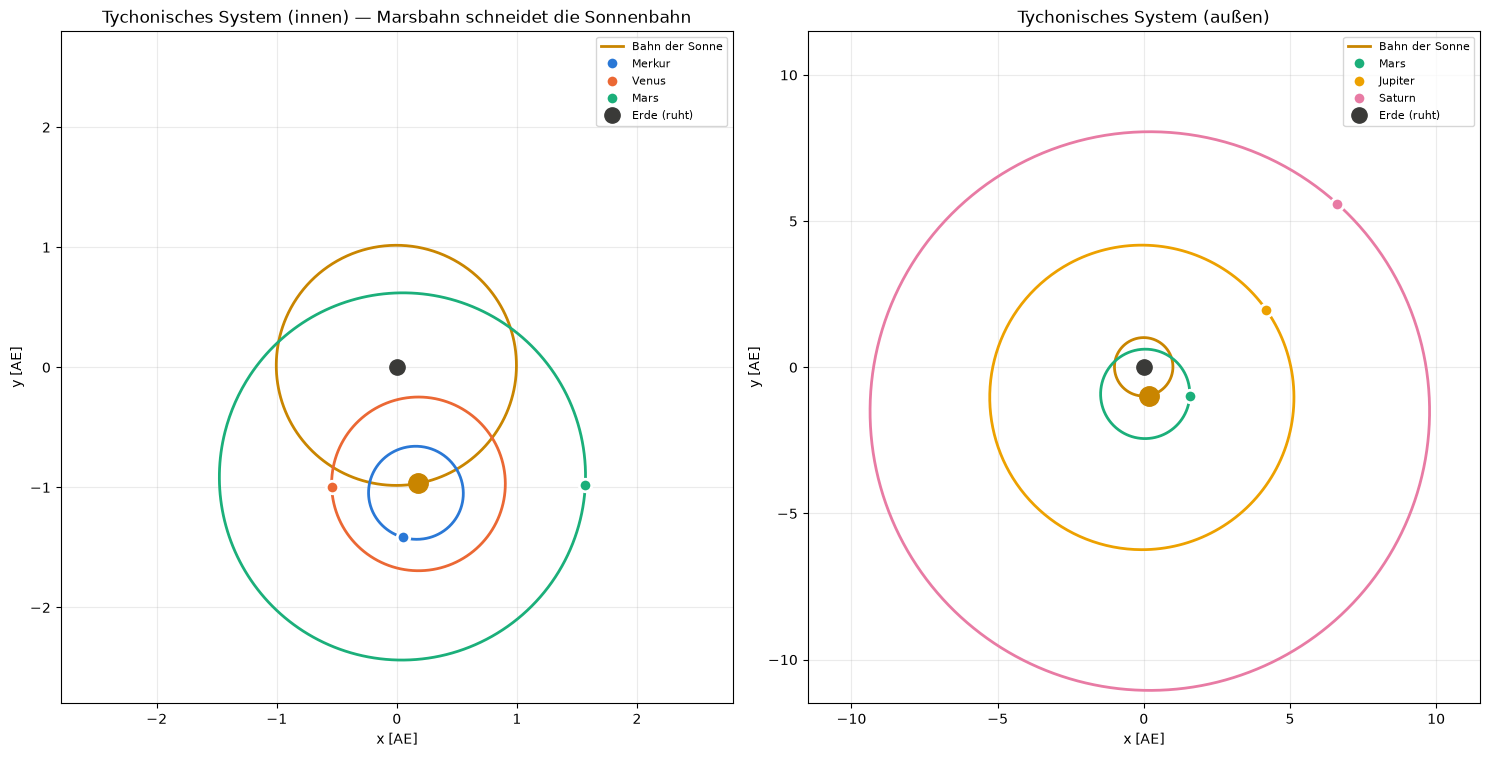

größte Abweichung Tycho ↔ Kopernikus: 0.0e+00 AE


In [7]:
def tycho(name, t):
    """Geozentrisch: Sonne um die Erde, Planeten um die Sonne."""
    sonne = -kopernikus_helio("Erde", t)          # Sonnenbahn um die ruhende Erde
    return sonne if name == "Sonne" else sonne + kopernikus_helio(name, t)


t, t0 = np.linspace(0, 32, 30000), 0.0
fig, axes = plt.subplots(1, 2, figsize=(15, 7.5))
for ax, grenze, namen in ((axes[0], 2.8, ["Merkur", "Venus", "Mars"]),
                          (axes[1], 11.5, ["Mars", "Jupiter", "Saturn"])):
    ax.plot(*tycho("Sonne", t[t < 1.01]).T, color=FARBE["Sonne"], lw=2, label="Bahn der Sonne")
    s0 = tycho("Sonne", t0)
    for n in namen:
        umlauf = np.linspace(0, ELEMENTE[n][4], 400)
        ax.plot(*(s0 + kopernikus_helio(n, umlauf)).T, color=FARBE[n], lw=2)   # Bahn um die Sonne (t0)
        ax.plot(*tycho(n, t0), "o", color=FARBE[n], ms=9, mec="white", mew=2, label=n)
    ax.plot(*s0, "o", color=FARBE["Sonne"], ms=14)
    ax.plot(0, 0, "o", color=FARBE["Erde"], ms=11, label="Erde (ruht)")
    ax.set(xlim=(-grenze, grenze), ylim=(-grenze, grenze), aspect="equal",
           xlabel="x [AE]", ylabel="y [AE]")
    ax.legend(loc="upper right", fontsize=8)
axes[0].set_title("Tychonisches System (innen) — Marsbahn schneidet die Sonnenbahn")
axes[1].set_title("Tychonisches System (außen)")
plt.tight_layout()
plt.show()

# Tycho und Kopernikus liefern exakt dieselben Sichtlinien:
d = max(np.abs(tycho(n, t) - kopernikus(n, t)).max() for n in PLANETEN)
print(f"größte Abweichung Tycho ↔ Kopernikus: {d:.1e} AE")

**Tycho und Kopernikus sind geometrisch identisch** — sie unterscheiden sich nur darin, welcher
Körper als ruhend gilt. Keine Positionsmessung kann zwischen ihnen entscheiden.

## 6. Kepler: Ellipsen

Kepler rechnete jahrelang mit Tychos Marsbeobachtungen und fand eine Abweichung von
**8 Bogenminuten** gegenüber dem besten Kreismodell. Er gab die Kreise auf:

1. **Ellipsensatz:** Planeten laufen auf Ellipsen, die Sonne steht in einem Brennpunkt.
2. **Flächensatz:** Der Fahrstrahl Sonne–Planet überstreicht in gleichen Zeiten gleiche Flächen.
3. **Harmonisches Gesetz** (1619): $T^2 / a^3$ ist für alle Planeten gleich.

Keplers Modell ist unsere Referenz aus Abschnitt 1. Wie gut kommt ihm die Ellipse durch den
Äquantkreis nahe? Hier für Mars mit übertriebener Exzentrizität:

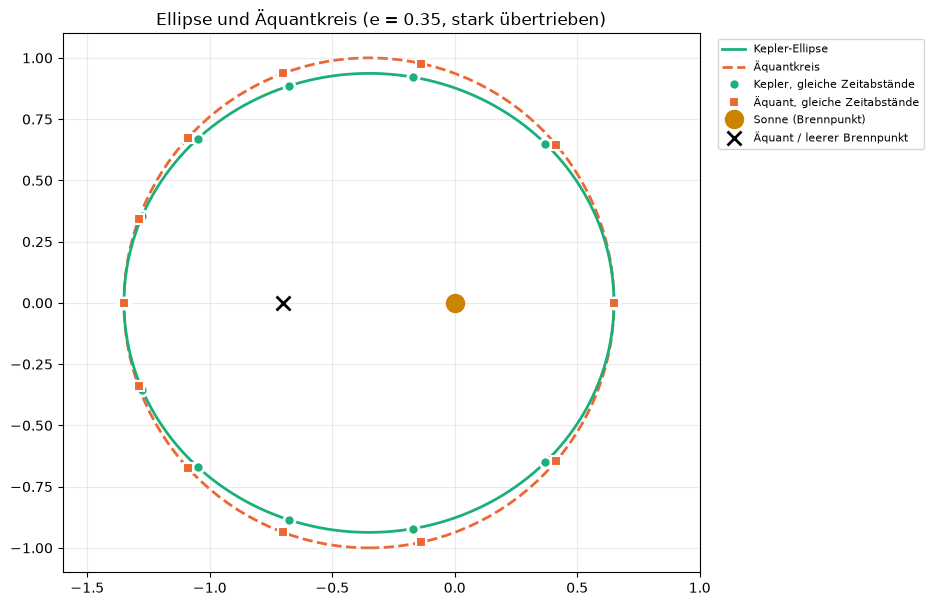

In [8]:
def ellipse_und_aequant(e, a=1.0, schritte=12):
    M = np.linspace(0, 2 * np.pi, schritte, endpoint=False)
    E = M.copy()
    for _ in range(50):
        E -= (E - e * np.sin(E) - M) / (1 - e * np.cos(E))
    kep = np.stack([a * (np.cos(E) - e), a * np.sqrt(1 - e**2) * np.sin(E)], axis=-1)
    # Äquantkreis: Mittelpunkt (−e·a), Äquant (−2e·a), gleichförmig vom Äquant aus
    Q, C = np.array([-2 * e * a, 0]), np.array([-e * a, 0])
    d = richtung(M)
    b = (Q - C) @ d.T
    s = -b + np.sqrt(b**2 - (np.sum((Q - C) ** 2) - a**2))
    return kep, Q + s[:, None] * d


e_zeig = 0.35
kep, aeq = ellipse_und_aequant(e_zeig)
E_ = np.linspace(0, 2 * np.pi, 400)

fig, ax = plt.subplots(figsize=(9, 7))
ax.plot(np.cos(E_) - e_zeig, np.sqrt(1 - e_zeig**2) * np.sin(E_), color=MODELL_FARBE["Kepler"],
        lw=2, label="Kepler-Ellipse")
ax.add_patch(Circle((-e_zeig, 0), 1, fill=False, color=MODELL_FARBE["Ptolemäus"], lw=2, ls="--"))
ax.plot([], [], color=MODELL_FARBE["Ptolemäus"], ls="--", lw=2, label="Äquantkreis")
ax.plot(*kep.T, "o", color=MODELL_FARBE["Kepler"], ms=8, mec="white", mew=2,
        label="Kepler, gleiche Zeitabstände")
ax.plot(*aeq.T, "s", color=MODELL_FARBE["Ptolemäus"], ms=7, mec="white", mew=1.5,
        label="Äquant, gleiche Zeitabstände")
ax.plot(0, 0, "o", color=FARBE["Sonne"], ms=13, label="Sonne (Brennpunkt)")
ax.plot(-2 * e_zeig, 0, "x", color="k", ms=10, mew=2, label="Äquant / leerer Brennpunkt")
ax.set(aspect="equal", xlim=(-1.6, 1.0), ylim=(-1.1, 1.1),
       title=f"Ellipse und Äquantkreis (e = {e_zeig}, stark übertrieben)")
ax.legend(loc="upper left", bbox_to_anchor=(1.02, 1), fontsize=8)
plt.show()

Der Äquant liegt genau im **leeren Brennpunkt** der Ellipse — Ptolemäus hatte, ohne es zu wissen,
Keplers Bewegung in erster Ordnung von $e$ schon richtig erfasst. Der Unterschied liegt in der
**Form** der Bahn (Kreis statt Ellipse), und die ist erst bei Tychos Genauigkeit sichtbar.

## 7. Alles eine Frage des Bezugssystems?

Rein kinematisch ist die Wahl des „Zentrums“ **frei**: Man kann dieselbe Bewegung von jedem
Körper aus beschreiben. Hier die *wahre* Bewegung (Kepler) mit vier verschiedenen Körpern in Ruhe.
Heliozentrisch sieht alles einfach aus — das ist Kopernikus' eigentliches Argument.

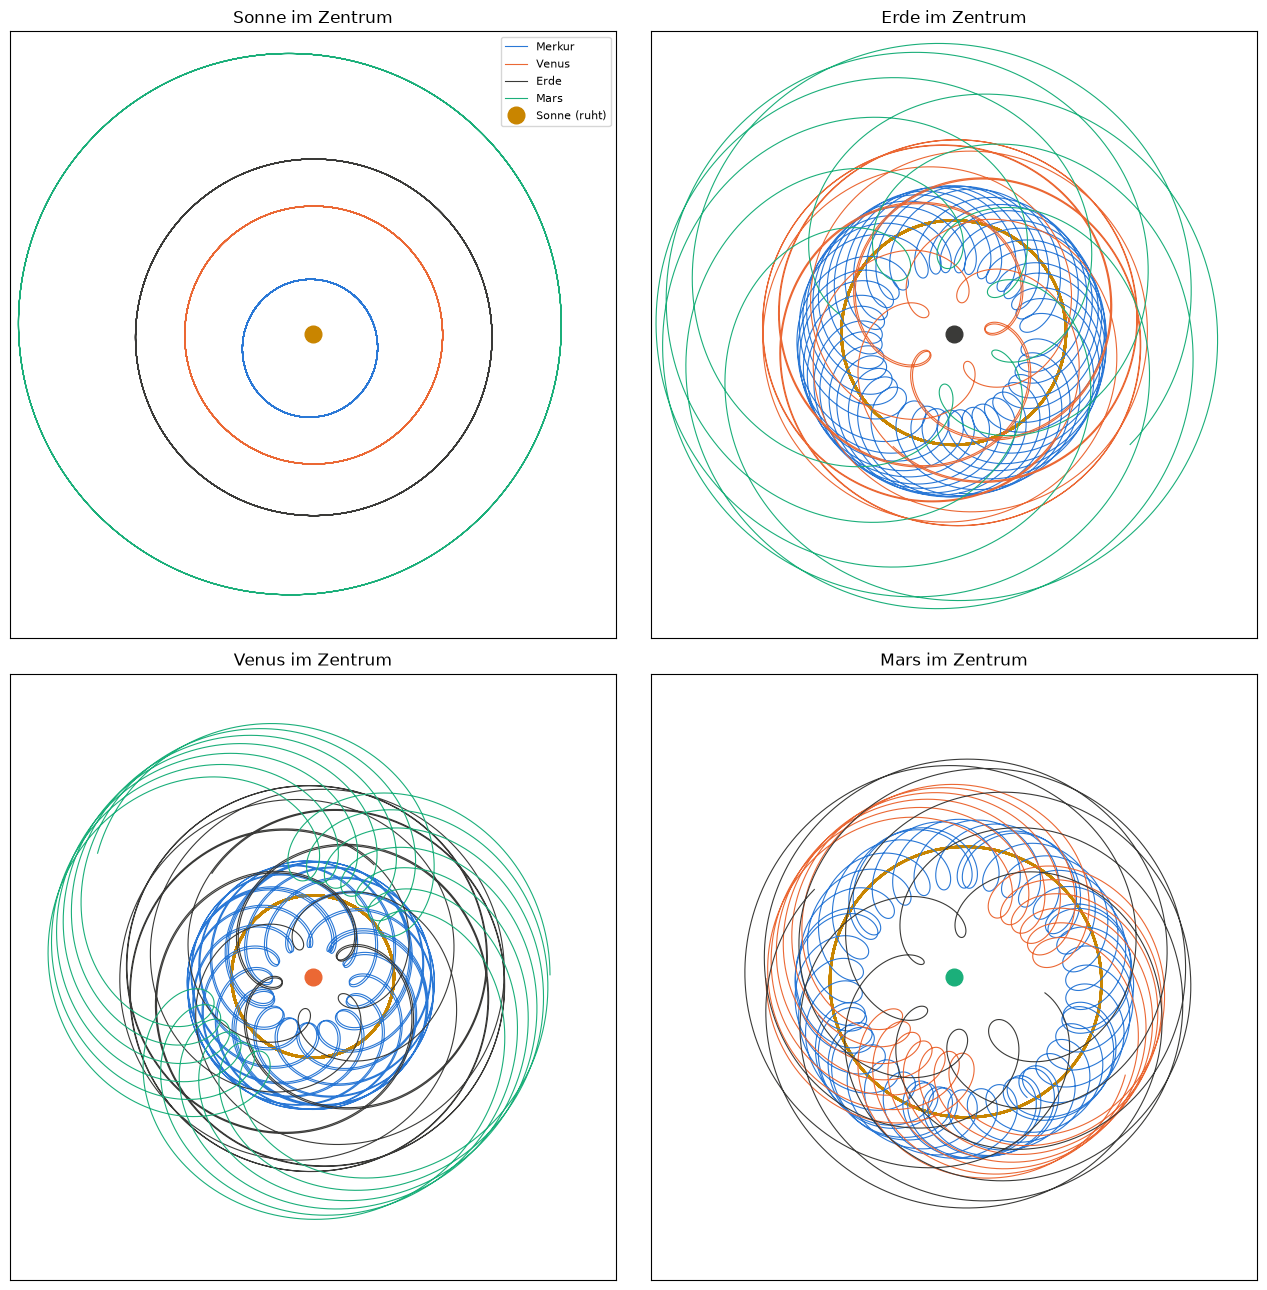

In [9]:
KOERPER = ["Sonne"] + list(ELEMENTE)


def bezugssystem(zentrum, t):
    """Positionen aller Körper relativ zum gewählten ruhenden Körper."""
    helio = {n: kepler(n, t) for n in ELEMENTE}
    helio["Sonne"] = np.zeros(np.shape(t) + (2,))
    return {n: helio[n] - helio[zentrum] for n in KOERPER if n != zentrum}


def zeichne_bezugssystem(ax, zentrum, jahre=12, grenze=2.6, namen=("Sonne", "Merkur", "Venus", "Erde", "Mars")):
    t = np.linspace(0, jahre, 20000)
    for n, p in bezugssystem(zentrum, t).items():
        if n in namen:
            ax.plot(*p.T, color=FARBE[n], lw=0.8 if n != "Sonne" else 1.8, label=n)
    ax.plot(0, 0, "o", color=FARBE[zentrum], ms=12, label=f"{zentrum} (ruht)")
    ax.set(xlim=(-grenze, grenze), ylim=(-grenze, grenze), aspect="equal", xticks=[], yticks=[])
    ax.set_title(f"{zentrum} im Zentrum")


fig, axes = plt.subplots(2, 2, figsize=(13, 13))
for ax, (zentrum, grenze) in zip(axes.flat, [("Sonne", 1.7), ("Erde", 2.7), ("Venus", 2.7), ("Mars", 3.4)]):
    zeichne_bezugssystem(ax, zentrum, grenze=grenze)
axes[0, 0].legend(loc="upper right", fontsize=8)
plt.tight_layout()
plt.show()

Mit `ipywidgets` kann man den ruhenden Körper selbst wählen (sonst statisches Beispiel):

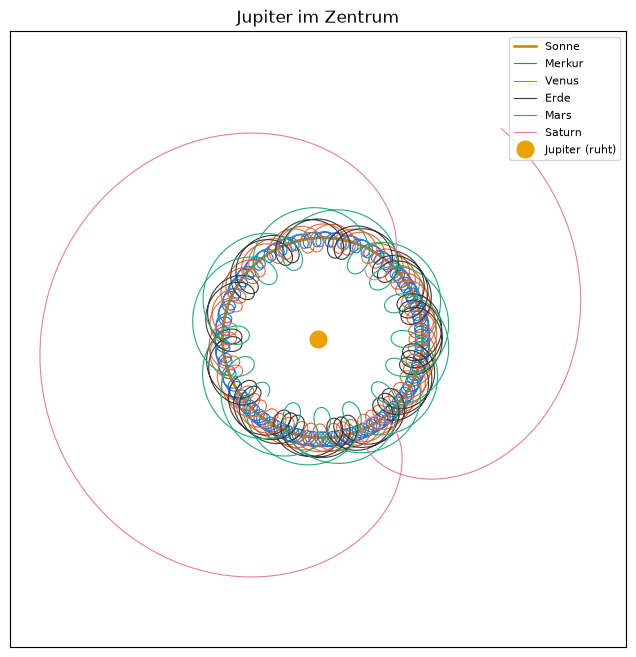

In [10]:
def bezugssystem_interaktiv(zentrum="Jupiter", jahre=30):
    fig, ax = plt.subplots(figsize=(8, 8))
    zeichne_bezugssystem(ax, zentrum, jahre=jahre, grenze=16, namen=KOERPER)
    ax.legend(loc="upper right", fontsize=8)
    plt.show()


try:
    from ipywidgets import interact, Dropdown, IntSlider

    interact(bezugssystem_interaktiv,
             zentrum=Dropdown(options=KOERPER, value="Jupiter", description="ruht:"),
             jahre=IntSlider(value=30, min=1, max=60, description="Jahre"))
except ImportError:
    bezugssystem_interaktiv("Jupiter", 30)

## 8. Genauigkeitswettbewerb

Alle Modelle sagen die **geozentrische Länge** voraus — das Einzige, was man vor dem Fernrohr
wirklich messen konnte. Wir vergleichen über 60 Jahre mit der Referenz. Zum Einordnen:

| Größe | Winkel |
|---|---|
| Messgenauigkeit mit bloßem Auge (Antike) | ≈ 10′ |
| Tycho Brahe (1580–1600) | ≈ 1–2′ |
| Monddurchmesser | ≈ 30′ |

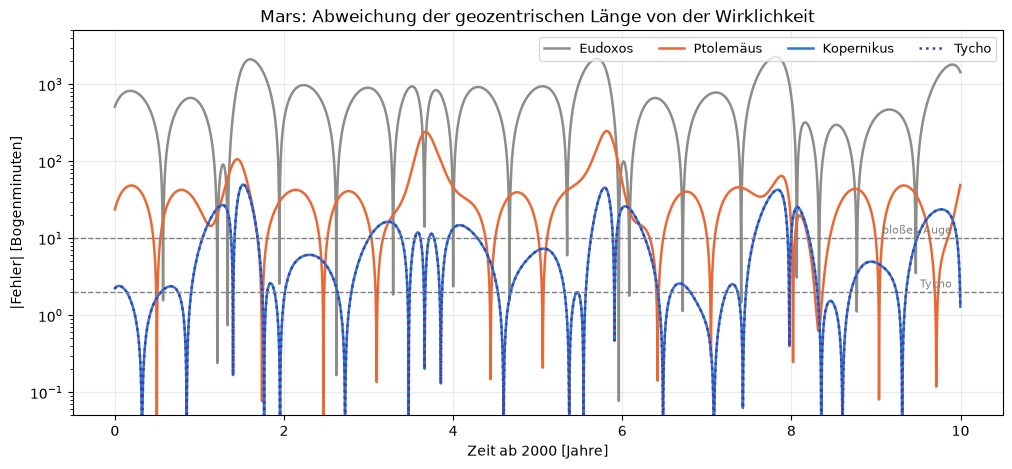

maximaler Fehler der geozentrischen Länge über 60 Jahre [Bogenminuten]

               Eudoxos   Ptolemäus  Kopernikus       Tycho
Sonne                —         0.7         0.3         0.3
Merkur           773.0       888.4        74.9        74.9
Venus           1682.6       123.9         1.6         1.6
Mars            2331.4       305.5        52.6        52.6
Jupiter          463.2        29.3         3.5         3.5
Saturn           424.6        14.3         4.0         4.0


In [11]:
MODELLE = {
    "Eudoxos":    lambda n, t: eudoxos(n, t, EUDOXOS_I[n]),
    "Ptolemäus":  lambda n, t: laenge(ptolemaeus(n, t)[0]),
    "Kopernikus": lambda n, t: laenge(kopernikus(n, t)),
    "Tycho":      lambda n, t: laenge(tycho(n, t)),
}

t = np.linspace(0, 60, 60 * 365)
fehler = {(m, n): winkelfehler(f(n, t), laenge(geo_referenz(n, t)))
          for m, f in MODELLE.items() for n in PLANETEN + ["Sonne"] if not (m == "Eudoxos" and n == "Sonne")}

fig, ax = plt.subplots(figsize=(12, 5))
tt = slice(0, 10 * 365)
for m in MODELLE:
    ls = ":" if m == "Tycho" else "-"
    ax.plot(t[tt], np.abs(fehler[m, "Mars"][tt]), color=MODELL_FARBE[m], lw=1.8, ls=ls, label=m)
ax.axhline(10, color="gray", lw=1, ls="--")
ax.text(9.9, 10 * 1.15, "bloßes Auge", ha="right", color="gray", fontsize=8)
ax.axhline(2, color="gray", lw=1, ls="--")
ax.text(9.9, 2 * 1.15, "Tycho", ha="right", color="gray", fontsize=8)
ax.set(yscale="log", ylim=(0.05, 5000), xlabel="Zeit ab 2000 [Jahre]",
       ylabel="|Fehler| [Bogenminuten]", title="Mars: Abweichung der geozentrischen Länge von der Wirklichkeit")
ax.legend(loc="upper right", ncol=4, fontsize=9)
plt.show()

print("maximaler Fehler der geozentrischen Länge über 60 Jahre [Bogenminuten]\n")
print(f"{'':<10}" + "".join(f"{m:>12}" for m in MODELLE))
for n in ["Sonne"] + PLANETEN:
    zeile = "".join(f"{np.abs(fehler[m, n]).max():>12.1f}" if (m, n) in fehler else f"{'—':>12}"
                    for m in MODELLE)
    print(f"{n:<10}{zeile}")

**Ergebnis:**

* **Eudoxos** liegt um viele Grad daneben — für die Vorhersage unbrauchbar.
* **Ptolemäus** liegt bei Mars bis zu **5°** daneben, besonders um die Opposition herum.
  Der Grund ist ein Strukturfehler: Der Epizykel ist ein *gleichförmiger* Kreis. Bei äußeren
  Planeten fehlt damit die Exzentrizität der Erdbahn, bei inneren die des Planeten selbst. Jede
  Bahn hat bei Ptolemäus nur **eine** Exzentrizität, obwohl es in Wirklichkeit **zwei** gibt.
* **Kopernikus** gibt *jeder* Bahn, auch der Erde, ihre eigene Exzentrizität. Mit perfekt
  angepassten Parametern (wie hier) wird er dadurch deutlich besser, bei Mars bis etwa 1°.
  Dieser Rest kommt von den Kreisen statt Ellipsen und wird bei der Opposition verstärkt,
  weil Mars dann nah ist. *Historisch* waren beide Modelle ähnlich ungenau (bis zu einige Grad),
  weil ihre Parameter aus ungenauen und alten Beobachtungen stammten.
* **Tycho** = Kopernikus, bis auf Rundungsfehler.
* Erst **Kepler** (die Referenz selbst) bringt den Fehler unter Tychos Messgenauigkeit.

Wenn die Positionen nicht entscheiden — was dann?

## 9. Beobachtungen, die entscheiden

### 9a. Helligkeit: der Abstand ändert sich

Mars ist in Opposition bis zu 50-mal heller als in Konjunktion. Bei Eudoxos hat er stets den
gleichen Abstand. Ptolemäus' Epizykel dagegen ändert den Abstand — nur die *absolute* Größe
blieb bei ihm unbestimmt, hier auf die richtigen Werte skaliert.

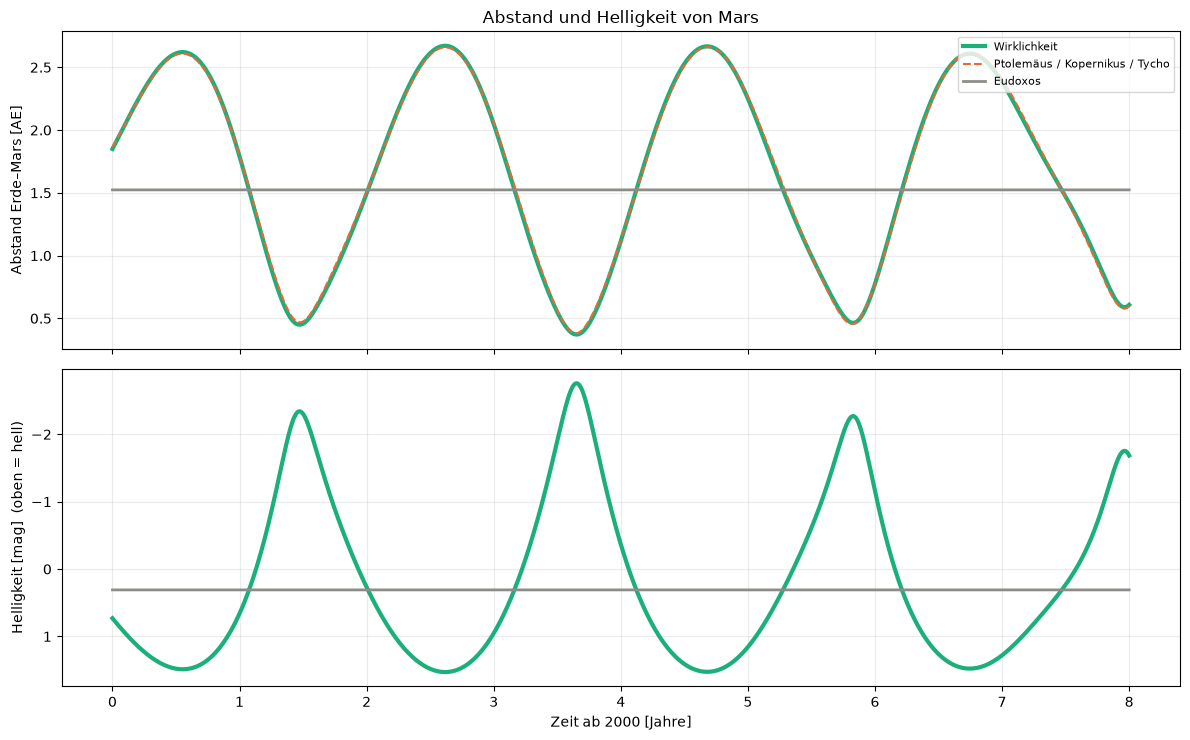

Helligkeitsbereich Mars: -2.8 … 1.5 mag  →  Faktor 52


In [12]:
t = np.linspace(0, 8, 5000)
r_ref = np.linalg.norm(geo_referenz("Mars", t), axis=-1)
r_ptol = np.linalg.norm(ptolemaeus("Mars", t)[0], axis=-1)
r_eud = np.full_like(t, ELEMENTE["Mars"][0])     # beliebig, aber konstant


def helligkeit(r_geo, r_helio=1.524, H=-1.52):
    # scheinbare Helligkeit (Magnitudo), ohne Phaseneffekt
    return H + 5 * np.log10(r_geo * r_helio)


fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(12, 7.5), sharex=True)
ax1.plot(t, r_ref, color=MODELL_FARBE["Kepler"], lw=3, label="Wirklichkeit")
ax1.plot(t, r_ptol, color=MODELL_FARBE["Ptolemäus"], lw=1.5, ls="--", label="Ptolemäus / Kopernikus / Tycho")
ax1.plot(t, r_eud, color=MODELL_FARBE["Eudoxos"], lw=2, label="Eudoxos")
ax1.set(ylabel="Abstand Erde–Mars [AE]", title="Abstand und Helligkeit von Mars")
ax1.legend(loc="upper right", fontsize=8)

ax2.plot(t, helligkeit(r_ref), color=MODELL_FARBE["Kepler"], lw=3)
ax2.plot(t, helligkeit(r_eud), color=MODELL_FARBE["Eudoxos"], lw=2)
ax2.invert_yaxis()
ax2.set(xlabel="Zeit ab 2000 [Jahre]", ylabel="Helligkeit [mag]  (oben = hell)")
plt.tight_layout()
plt.show()

m = helligkeit(r_ref)
print(f"Helligkeitsbereich Mars: {m.min():.1f} … {m.max():.1f} mag"
      f"  →  Faktor {10 ** (0.4 * (m.max() - m.min())):.0f}")

→ **Eudoxos scheitert** schon am bloßen Auge. Alle anderen Modelle bestehen den Test.

### 9b. Die Phasen der Venus (Galilei, 1610)

Bei Ptolemäus liegt der Venus-Epizykel ganz **unterhalb der Sonne**, auf der Linie Erde–Sonne.
Die Venus stünde dann nie hinter der Sonne und wäre stets eine Sichel. Bei Kopernikus *und*
Tycho umkreist sie die Sonne und zeigt den vollen Phasenzyklus — wie Galilei mit dem Fernrohr sah.

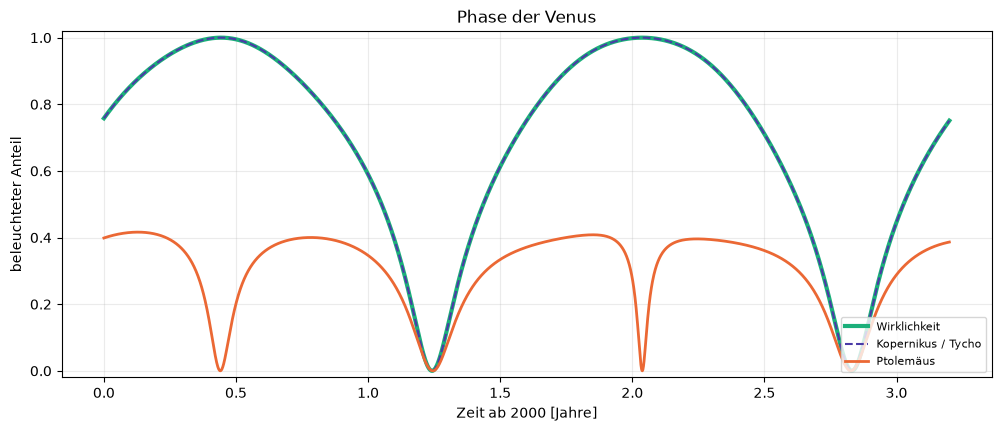

In [13]:
def beleuchtet(planet, sonne, erde=np.zeros(2)):
    # beleuchteter Anteil k = (1 + cos φ) / 2, φ = Winkel Sonne–Planet–Erde
    u, v = sonne - planet, erde - planet
    cos_phi = np.sum(u * v, -1) / (np.linalg.norm(u, axis=-1) * np.linalg.norm(v, axis=-1))
    return 0.5 * (1 + cos_phi)


t = np.linspace(0, 3.2, 3000)
sonne_ref = geo_referenz("Sonne", t)
venus_ptol, zentrum = ptolemaeus("Venus", t)
# Ptolemäus: Epizykel UNTER der Sonne → auf 0,55 der Sonnenentfernung skalieren
venus_ptol = 0.55 * venus_ptol
sonne_ptol = ptolemaeus("Sonne", t)[0]

fig, ax = plt.subplots(figsize=(12, 4.5))
ax.plot(t, beleuchtet(geo_referenz("Venus", t), sonne_ref), color=MODELL_FARBE["Kepler"], lw=3,
        label="Wirklichkeit")
ax.plot(t, beleuchtet(tycho("Venus", t), tycho("Sonne", t)), color=MODELL_FARBE["Tycho"], lw=1.5,
        ls="--", label="Kopernikus / Tycho")
ax.plot(t, beleuchtet(venus_ptol, sonne_ptol), color=MODELL_FARBE["Ptolemäus"], lw=2,
        label="Ptolemäus")
ax.set(xlabel="Zeit ab 2000 [Jahre]", ylabel="beleuchteter Anteil",
       ylim=(-0.02, 1.02), title="Phase der Venus")
ax.legend(loc="lower right", fontsize=8)
plt.show()

→ **Ptolemäus scheitert.** Tycho aber besteht auch diesen Test — deshalb war das tychonische
System im 17. Jahrhundert der wichtigste Konkurrent von Kopernikus.

### 9c. Die Fixsternparallaxe

Bewegt sich die Erde um die Sonne, müssten nahe Sterne im Laufe des Jahres eine kleine
**Parallaxenellipse** am Himmel beschreiben (große Halbachse $p = 1\,\text{AE}/d$, kleine
$p\sin\beta$ bei ekliptikaler Breite $\beta$). Bei Ptolemäus und Tycho ruht die Erde: keine
Parallaxe. Tycho sah nichts — seine Messgenauigkeit war etwa 1′.

Gemessen wurde die erste Parallaxe erst **1838** von Bessel (61 Cygni: 0,29″), also mehr als
200-mal kleiner als Tychos Grenze.

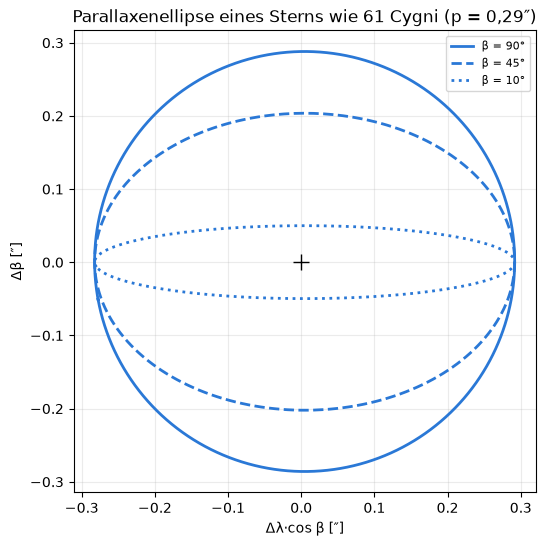

Wie nah müsste ein Stern sein, damit Tycho (1′ = 60″) die Parallaxe sieht?
  d < 1 AE / 60″ = 3,438 AE   (Saturn: 9,5 AE; nächster Stern: ≈ 268 000 AE)


In [14]:
t = np.linspace(0, 1, 400)
erde = kepler("Erde", t)
BOGENSEK = 180 / np.pi * 3600

fig, ax = plt.subplots(figsize=(8, 6))
p = 0.287                                 # Parallaxe von 61 Cygni [Bogensekunden]
d = BOGENSEK / p                          # Abstand in AE
for beta_grad, stil in ((90, "-"), (45, "--"), (10, ":")):
    beta = np.radians(beta_grad)
    # Stern bei Länge 0°, Breite β: scheinbare Verschiebung = −(Erdposition ⊥ Sichtlinie) / d
    dl = -erde[:, 1] / d * BOGENSEK                    # entlang der Ekliptik
    db = erde[:, 0] * np.sin(beta) / d * BOGENSEK      # senkrecht dazu
    ax.plot(dl, db, color=MODELL_FARBE["Kopernikus"], ls=stil, lw=2, label=f"β = {beta_grad}°")
ax.plot(0, 0, "+", color="k", ms=12)
ax.set(aspect="equal", xlabel="Δλ·cos β [″]", ylabel="Δβ [″]",
       title="Parallaxenellipse eines Sterns wie 61 Cygni (p = 0,29″)")
ax.legend(loc="upper right", fontsize=8)
plt.show()

print("Wie nah müsste ein Stern sein, damit Tycho (1′ = 60″) die Parallaxe sieht?")
print(f"  d < 1 AE / 60″ = {BOGENSEK / 60:,.0f} AE   (Saturn: 9,5 AE; nächster Stern: ≈ 268 000 AE)")

Tycho folgerte: Entweder die Erde ruht, oder die Sterne sind unvorstellbar weit weg (und dann,
bei ihrer scheinbaren Größe von einigen Bogenminuten, unvorstellbar groß). Er wählte das
Erste — mit guten Gründen, aber falsch. Die scheinbare Sterngröße war ein Artefakt des Auges.

### 9d. Die Ordnung der Welt: Abstände und das 3. Keplersche Gesetz

Bei Ptolemäus kennt man pro Planet nur das Verhältnis Epizykel : Deferent; die Reihenfolge der
Planeten ist Konvention. Im heliozentrischen System folgen die **Abstände aus der Geometrie**,
z. B. für innere Planeten aus der größten Elongation: $a = \sin\varepsilon_{\max}$.
(Bei Merkur liegt das daneben, weil seine Bahn stark exzentrisch ist.) Für äußere Planeten
wird aus dem ptolemäischen Epizykelverhältnis direkt der Abstand: Kopernikus hat genau so
Ptolemäus' Zahlen in eine Karte des Planetensystems verwandelt. Mit den Abständen ergibt sich Keplers Gesetz $T^2 \propto a^3$ — ein Zusammenhang, den nur ein
Sonnen-zentriertes System zeigen kann.

Planet   Methode                            a gemessen   a wahr
Merkur   größte Elongation 27.8°                 0.467    0.387


Venus    größte Elongation 47.1°                 0.733    0.723
Mars     Almagest: r/R = 39.5/60 → a = 60/r      1.519    1.524
Jupiter  Almagest: r/R = 11.5/60 → a = 60/r      5.217    5.203
Saturn   Almagest: r/R = 6.5/60 → a = 60/r       9.231    9.555


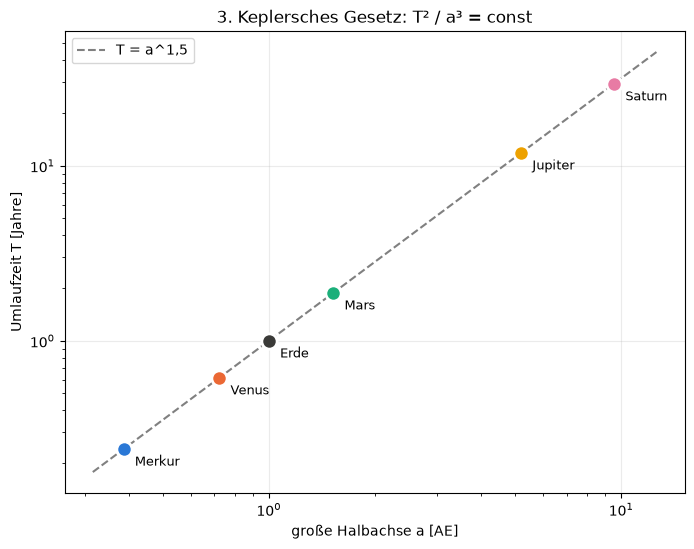

T²/a³: [1.     1.     1.     1.0001 0.9993 0.9941]


In [15]:
t = np.linspace(0, 20, 40000)
print(f"{'Planet':<9}{'Methode':<34}{'a gemessen':>11}{'a wahr':>9}")
for n in ["Merkur", "Venus"]:
    elong = np.abs(winkelfehler(laenge(geo_referenz(n, t)), laenge(geo_referenz("Sonne", t)))) / 60
    print(f"{n:<9}{'größte Elongation ' + f'{elong.max():.1f}°':<34}"
          f"{np.sin(np.radians(elong.max())):>11.3f}{ELEMENTE[n][0]:>9.3f}")
# äußere Planeten: Epizykel = Erdbahn (1 AE)  →  a = Deferent / Epizykel,
# mit Ptolemäus' Radien aus dem Almagest (Deferent = 60 Einheiten)
ALMAGEST_EPIZYKEL = {"Mars": 39.5, "Jupiter": 11.5, "Saturn": 6.5}
for n, r in ALMAGEST_EPIZYKEL.items():
    print(f"{n:<9}{f'Almagest: r/R = {r}/60 → a = 60/r':<34}{60 / r:>11.3f}{ELEMENTE[n][0]:>9.3f}")

a = np.array([ELEMENTE[n][0] for n in ELEMENTE])
T = np.array([ELEMENTE[n][4] for n in ELEMENTE])
fig, ax = plt.subplots(figsize=(8, 6))
a_lin = np.logspace(-0.5, 1.1, 50)
ax.plot(a_lin, a_lin**1.5, color="gray", lw=1.5, ls="--", label="T = a^1,5")
for n, ai, Ti in zip(ELEMENTE, a, T):
    ax.plot(ai, Ti, "o", color=FARBE[n], ms=11, mec="white", mew=2)
    ax.annotate(n, (ai, Ti), textcoords="offset points", xytext=(8, -12), fontsize=9)
ax.set(xscale="log", yscale="log", xlabel="große Halbachse a [AE]", ylabel="Umlaufzeit T [Jahre]",
       title="3. Keplersches Gesetz: T² / a³ = const")
ax.legend()
plt.show()
print("T²/a³:", np.round(T**2 / a**3, 4))

## 10. Newton: warum die Planeten so laufen

Alle bisherigen Weltbilder sind **Kinematik** — sie beschreiben, *wie* sich die Planeten
bewegen. Newton lieferte 1687 die **Dynamik**: Die Sonne zieht jeden Planeten mit

$$\vec F = -\frac{G M m}{r^2}\,\hat r$$

an. In astronomischen Einheiten (AE, Jahr) gilt $GM_\odot = 4\pi^2$. Wir integrieren die
Bewegungsgleichung numerisch (Velocity-Verlet) und sehen, dass **alle drei Keplerschen Gesetze
herauskommen** — ohne dass wir sie hineingesteckt haben.

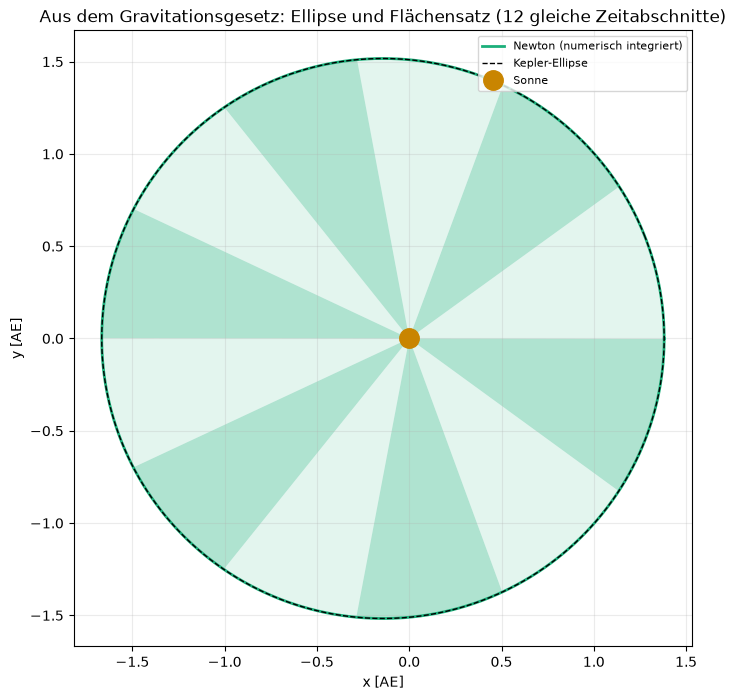

Bahn schließt sich nach T: Abstand Start–Ende = 1.6e-03 AE
Flächen je Abschnitt: min 0.60424, max 0.60617 AE²  (gleich!)


In [16]:
GM = 4 * np.pi**2                          # AE³/Jahr² (Sonne)


def verlet(beschl, r0, v0, dt, schritte):
    # Velocity-Verlet-Integration; r0, v0: Arrays (N, 2)
    r, v = np.array(r0, float), np.array(v0, float)
    bahn = np.empty((schritte + 1,) + r.shape)
    bahn[0] = r
    a = beschl(r)
    for k in range(schritte):
        r = r + v * dt + 0.5 * a * dt**2
        a_neu = beschl(r)
        v = v + 0.5 * (a + a_neu) * dt
        a = a_neu
        bahn[k + 1] = r
    return bahn


def sonne_zieht(r):
    return -GM * r / np.linalg.norm(r, axis=-1, keepdims=True) ** 3


# Mars startet im Perihel mit der Vis-viva-Geschwindigkeit
a_m, e_m = ELEMENTE["Mars"][:2]
r_p = a_m * (1 - e_m)
v_p = np.sqrt(GM * (1 + e_m) / r_p)
dt, jahre = 0.0005, ELEMENTE["Mars"][4]
bahn = verlet(sonne_zieht, [[r_p, 0]], [[0, v_p]], dt, int(jahre / dt))[:, 0]

# Flächensatz: überstrichene Fläche je Zeitabschnitt
abschnitte = np.linspace(0, len(bahn) - 1, 13).astype(int)
flaechen = []
fig, ax = plt.subplots(figsize=(9, 8))
for k, (i0, i1) in enumerate(zip(abschnitte[:-1], abschnitte[1:])):
    seg = bahn[i0:i1 + 1]
    flaechen.append(0.5 * np.sum(seg[:-1, 0] * seg[1:, 1] - seg[1:, 0] * seg[:-1, 1]))
    ax.fill(np.r_[0, seg[:, 0]], np.r_[0, seg[:, 1]],
            color=FARBE["Mars"], alpha=0.35 if k % 2 else 0.12, lw=0)
ax.plot(*bahn.T, color=FARBE["Mars"], lw=2, label="Newton (numerisch integriert)")
kep = kepler("Mars", np.linspace(0, jahre, 400))
c, s = np.cos(-np.radians(ELEMENTE["Mars"][2])), np.sin(-np.radians(ELEMENTE["Mars"][2]))
ax.plot(c * kep[:, 0] - s * kep[:, 1], s * kep[:, 0] + c * kep[:, 1], color="k", lw=1, ls="--",
        label="Kepler-Ellipse")
ax.plot(0, 0, "o", color=FARBE["Sonne"], ms=14, label="Sonne")
ax.set(aspect="equal", xlabel="x [AE]", ylabel="y [AE]",
       title="Aus dem Gravitationsgesetz: Ellipse und Flächensatz (12 gleiche Zeitabschnitte)")
ax.legend(loc="upper right", fontsize=8)
plt.show()

print(f"Bahn schließt sich nach T: Abstand Start–Ende = {np.linalg.norm(bahn[-1] - bahn[0]):.1e} AE")
print(f"Flächen je Abschnitt: min {min(flaechen):.5f}, max {max(flaechen):.5f} AE²  (gleich!)")

### Nicht einmal die Sonne ruht

Nach Newtons drittem Gesetz zieht auch jeder Planet an der Sonne. Das echte Zentrum ist der
**Schwerpunkt** des Sonnensystems. Wir simulieren Sonne, Jupiter und Saturn gemeinsam: Die
Sonne taumelt um den Schwerpunkt, zeitweise um mehr als ihren eigenen Radius (0,00465 AE).

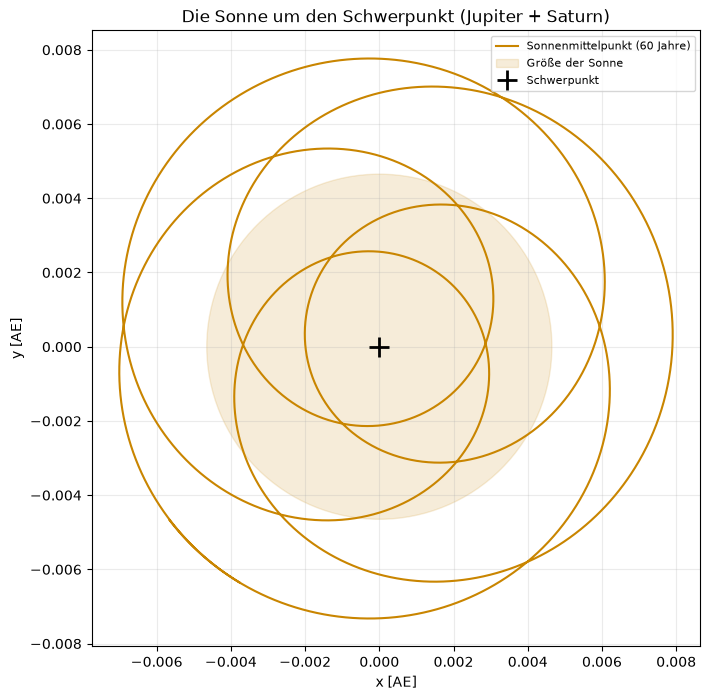

größter Abstand Sonne–Schwerpunkt: 0.0080 AE = 1.7 Sonnenradien


In [17]:
MASSE = np.array([1.0, 9.546e-4, 2.858e-4])        # Sonne, Jupiter, Saturn (Sonnenmassen)


def gegenseitig(r):
    a = np.zeros_like(r)
    for i in range(len(r)):
        for j in range(len(r)):
            if i != j:
                d = r[j] - r[i]
                a[i] += GM * MASSE[j] * d / np.linalg.norm(d) ** 3
    return a


r0 = np.array([[0, 0], kepler("Jupiter", 0), kepler("Saturn", 0)])
v0 = np.zeros_like(r0)
for k, n in ((1, "Jupiter"), (2, "Saturn")):
    v0[k] = (kepler(n, 1e-4) - kepler(n, -1e-4)) / 2e-4
# Schwerpunkt ruht im Ursprung
v0 -= (MASSE[:, None] * v0).sum(0) / MASSE.sum()
r0 -= (MASSE[:, None] * r0).sum(0) / MASSE.sum()

dt, jahre = 0.01, 60
bahn = verlet(gegenseitig, r0, v0, dt, int(jahre / dt))
sonne = bahn[:, 0]

fig, ax = plt.subplots(figsize=(8, 8))
ax.plot(*sonne.T, color=FARBE["Sonne"], lw=1.5, label="Sonnenmittelpunkt (60 Jahre)")
ax.add_patch(Circle((0, 0), 0.00465, color=FARBE["Sonne"], alpha=0.15, label="Größe der Sonne"))
ax.plot(0, 0, "+", color="k", ms=14, mew=2, label="Schwerpunkt")
ax.set(aspect="equal", xlabel="x [AE]", ylabel="y [AE]", title="Die Sonne um den Schwerpunkt (Jupiter + Saturn)")
ax.legend(loc="upper right", fontsize=8)
plt.show()
print(f"größter Abstand Sonne–Schwerpunkt: {np.linalg.norm(sonne, axis=1).max():.4f} AE "
      f"= {np.linalg.norm(sonne, axis=1).max() / 0.00465:.1f} Sonnenradien")

## 11. Animation: dasselbe Sonnensystem, drei Weltbilder

Ptolemäus, Tycho und Kopernikus nebeneinander (Venus, Sonne, Erde, Mars über zwei Mars-Synodenperioden).
Die Zelle erzeugt eine abspielbare HTML-Animation — die Ausgabe ist im gespeicherten Notebook
nicht enthalten, um die Datei klein zu halten. Einfach ausführen.

In [ ]:
from matplotlib.animation import FuncAnimation
from IPython.display import HTML

t = np.linspace(0, 2 * synodisch("Mars"), 150)
namen = ["Sonne", "Venus", "Mars"]
systeme = {
    "Ptolemäus (Erde ruht)":  {n: ptolemaeus(n, t)[0] for n in namen} | {"Erde": np.zeros((len(t), 2))},
    "Tycho (Erde ruht)":      {n: tycho(n, t) for n in namen} | {"Erde": np.zeros((len(t), 2))},
    "Kopernikus (Sonne ruht)": {n: kopernikus_helio(n, t) for n in ["Venus", "Mars", "Erde"]}
                               | {"Sonne": np.zeros((len(t), 2))},
}

fig, axes = plt.subplots(1, 3, figsize=(12, 4.3), dpi=70)
spuren, punkte = [], []
for ax, (titel, pos) in zip(axes, systeme.items()):
    ax.set(aspect="equal", xlim=(-2.9, 2.9), ylim=(-2.9, 2.9), title=titel, xticks=[], yticks=[])
    for n, p in pos.items():
        spur, = ax.plot([], [], color=FARBE[n], lw=1)
        punkt, = ax.plot([], [], "o", color=FARBE[n], ms=12 if n == "Sonne" else 8)
        spuren.append((spur, p))
        punkte.append((punkt, p))


def bild(i):
    for spur, p in spuren:
        spur.set_data(*p[: i + 1].T)
    for punkt, p in punkte:
        punkt.set_data([p[i, 0]], [p[i, 1]])
    return [s for s, _ in spuren] + [q for q, _ in punkte]


anim = FuncAnimation(fig, bild, frames=len(t), interval=40, blit=True)
plt.close(fig)
HTML(anim.to_jshtml())

## 12. Einordnung

| | Eudoxos | Ptolemäus | Kopernikus | Tycho | Kepler | Newton |
|---|---|---|---|---|---|---|
| Zentrum | Erde | Erde (fast) | Sonne | Erde | Sonne (Brennpunkt) | Schwerpunkt |
| Bahnen | Sphären | Kreise, Epizykel, Äquant | Kreise, Epizykelchen | Kreise | Ellipsen | aus $F\propto 1/r^2$ |
| Positionsfehler Mars (hier) | ≈ 40° | ≈ 5° | ≈ 1° | ≈ 1° | Referenz | Referenz |
| Helligkeitsschwankung | ✗ | ✓ | ✓ | ✓ | ✓ | ✓ |
| Venusphasen | ✗ | ✗ | ✓ | ✓ | ✓ | ✓ |
| Fixsternparallaxe | keine | keine | ja, winzig | keine | ja | ja |
| $T^2\propto a^3$ erkennbar | ✗ | ✗ | (✓) | (✓) | ✓ | ✓ (hergeleitet) |
| erklärt *warum* | ✗ | ✗ | ✗ | ✗ | (✗) | ✓ |

**Lehren**

* **Mehrere Modelle können dieselben Daten gleich gut beschreiben.** Kopernikus und Tycho sind
  geometrisch identisch; Ptolemäus liefert dieselben Richtungen. Die Entscheidung fiel durch
  *neue Arten* von Beobachtungen (Phasen, Parallaxe) und durch höhere *Genauigkeit* (Keplers 8′).
* **Einfachheit** war ein Argument: heliozentrisch wird die Rückläufigkeit „geschenkt“ und die
  Abstände der Planeten sind festgelegt.
* **Bewegung ist relativ** (Abschnitt 7) — physikalisch ausgezeichnet ist erst bei Newton das
  Schwerpunktsystem, weil dort die Bewegungsgleichungen am einfachsten sind.

## Aufgaben

1. Warum ist der beste Neigungswinkel $i$ bei Eudoxos für Venus so viel größer als für
   Saturn? Vergleiche mit der größten Elongation bzw. der Größe der Rückläufigkeitsschleife.
2. Setze in `aequantkreis` für Mars den Äquant auf den Kreismittelpunkt (`aequant=1.0`) und
   verdoppele stattdessen die Exzentrizität (`mitte=2.0, aequant=2.0`, „Hipparch-Modell“).
   Wie groß wird der Fehler? Warum war der Äquant ein so großer Fortschritt?
3. Ab welchem Faktor (statt 0,55 in Abschnitt 9b) kann Ptolemäus' Venus eine volle Scheibe
   zeigen? Was bedeutet das für die Anordnung von Venus und Sonne?
4. Starte Mars in Abschnitt 10 mit 10 % mehr Geschwindigkeit. Wie ändern sich $a$, $e$ und $T$?
   Gilt $T^2/a^3 = 1$ weiter?

In [19]:
# Lösungen

# Aufgabe 1: Die Hippopede reicht ±i entlang der Ekliptik → i ≈ halbe Schleifenbreite
t = np.linspace(0, 20, 20000)
for n in ["Venus", "Saturn"]:
    elong = np.abs(winkelfehler(laenge(geo_referenz(n, t)),
                                np.degrees(mittlere_laenge("Erde", t) + np.pi) if n in INNEN
                                else np.degrees(mittlere_laenge(n, t)))) / 60
    print(f"1) {n:<7} bestes i = {np.degrees(EUDOXOS_I[n]):5.1f}°,  "
          f"größte Abweichung von der mittleren Position = {elong.max():5.1f}°")

# Aufgabe 2
t = np.linspace(0, 30, 20000)
ref = laenge(geo_referenz("Mars", t))
for label, kw in (("Äquant (Ptolemäus)", {}), ("Exzenter 2e (Hipparch)", dict(mitte=2.0, aequant=2.0))):
    p = aequantkreis("Mars", t, **kw) + mittlere_sonne(t)
    print(f"2) {label:<24} max. Fehler {np.abs(winkelfehler(laenge(p), ref)).max():6.1f}′")

# Aufgabe 3: voller Zyklus nur, wenn der Epizykel die Sonne umschließt, d. h. Mittelpunkt = Sonne
t = np.linspace(0, 3.2, 3000)
for f in (0.55, 0.9, 1.0):
    k = beleuchtet(f * ptolemaeus("Venus", t)[0], ptolemaeus("Sonne", t)[0])
    print(f"3) Faktor {f:.2f}: beleuchteter Anteil max. {k.max():.2f}")
a_v = ELEMENTE["Venus"][0]
print(f"   → Ab Faktor 1/(1 + a) = {1 / (1 + a_v):.2f} reicht der Epizykel hinter die Sonne.")
print("   → Faktor 1: der Epizykelmittelpunkt IST die Sonne — das ist Tychos System.")

# Aufgabe 4
bahn4 = verlet(sonne_zieht, [[r_p, 0]], [[0, 1.1 * v_p]], 0.001, 12000)[:, 0]
r = np.linalg.norm(bahn4, axis=1)
a4, e4 = (r.max() + r.min()) / 2, (r.max() - r.min()) / (r.max() + r.min())
print(f"4) a = {a4:.3f} AE, e = {e4:.3f}, T = √a³ = {a4**1.5:.2f} Jahre (Vis-viva: "
      f"a = {1 / (2 / r_p - (1.1 * v_p) ** 2 / GM):.3f} AE)")

1) Venus   bestes i =  41.5°,  größte Abweichung von der mittleren Position =  48.2°
1) Saturn  bestes i =   6.0°,  größte Abweichung von der mittleren Position =  12.3°
2) Äquant (Ptolemäus)       max. Fehler  305.5′
2) Exzenter 2e (Hipparch)   max. Fehler  806.8′
3) Faktor 0.55: beleuchteter Anteil max. 0.42
3) Faktor 0.90: beleuchteter Anteil max. 1.00
3) Faktor 1.00: beleuchteter Anteil max. 1.00
   → Ab Faktor 1/(1 + a) = 0.58 reicht der Epizykel hinter die Sonne.
   → Faktor 1: der Epizykelmittelpunkt IST die Sonne — das ist Tychos System.


4) a = 2.040 AE, e = 0.323, T = √a³ = 2.91 Jahre (Vis-viva: a = 2.040 AE)
